In [ ]:
# SZÜKSÉGES KÖNYVTÁRAK IMPORTÁLÁSA
import pandas as pd
import numpy as np

In [ ]:
# ADATOK BETÖLTÉSE
from google.colab import files
df = pd.read_csv('Barcelona 2025.09.14.csv')
df = df.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19410 entries, 0 to 19409
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              19410 non-null  int64  
 1   name                            19410 non-null  object 
 2   host_id                         19410 non-null  int64  
 3   host_name                       19405 non-null  object 
 4   neighbourhood_group             19410 non-null  object 
 5   neighbourhood                   19410 non-null  object 
 6   latitude                        19410 non-null  float64
 7   longitude                       19410 non-null  float64
 8   room_type                       19410 non-null  object 
 9   price                           15276 non-null  float64
 10  minimum_nights                  19410 non-null  int64  
 11  number_of_reviews               19410 non-null  int64  
 12  last_review                     

In [ ]:
# HIÁNYZÓ ADATOK KISZŰRÉSE
print("Hiányzó értékek száma:")
print(df.isnull().sum())

Hiányzó értékek száma:
id                                   0
name                                 0
host_id                              0
host_name                            5
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             4134
minimum_nights                       0
number_of_reviews                    0
last_review                       4989
reviews_per_month                 4989
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           5480
dtype: int64


In [ ]:
# HIÁNYZÓ ÉRTÉKEK KEZELÉSE
df = df.dropna(subset=['price'])

print("Tisztítás után:")
print(df.isnull().sum())


Tisztítás után:
id                                   0
name                                 0
host_id                              0
host_name                            3
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       3486
reviews_per_month                 3486
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           3534
dtype: int64


In [ ]:
#ÚJ VÁTOZÓ LÉTREHOZÁSA 0-NINCS, 1-VAN ÉRTÉKELÉS
df['has_reviews'] = df['reviews_per_month'].notna().astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15276 entries, 0 to 19409
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              15276 non-null  int64  
 1   name                            15276 non-null  object 
 2   host_id                         15276 non-null  int64  
 3   host_name                       15273 non-null  object 
 4   neighbourhood_group             15276 non-null  object 
 5   neighbourhood                   15276 non-null  object 
 6   latitude                        15276 non-null  float64
 7   longitude                       15276 non-null  float64
 8   room_type                       15276 non-null  object 
 9   price                           15276 non-null  float64
 10  minimum_nights                  15276 non-null  int64  
 11  number_of_reviews               15276 non-null  int64  
 12  last_review                     11790

In [ ]:
# DUPLIKÁT SOROK ELLENŐRZÉSE
duplicate = df[df.duplicated()]
print("Duplikált sorok száma:", df.duplicated().sum())
df = df.drop_duplicates()
print("Tisztítás után:", df.duplicated().sum())

Duplikált sorok száma: 0
Tisztítás után: 0


In [ ]:
# ADATTÍPUSOK KONVERTÁLÁSA
df['last_review'] = pd.to_datetime(df['last_review'], errors = 'coerce')

# KATEGÓRIÁK OPTIMALIZÁLÁSA
df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')
df['neighbourhood'] = df['neighbourhood'].astype('category')
df['room_type'] = df['room_type'].astype('category')

# ELLENŐRZÉS
print (df.dtypes)

id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                     category
neighbourhood                           category
latitude                                 float64
longitude                                float64
room_type                               category
price                                    float64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
number_of_reviews_ltm                      int64
license                                   object
has_reviews                                int64
dtype: object


In [ ]:
# OUTLIEREK KEZELÉSE
# Price: kiszűröm a nagyon magas vagy nagyon alacsony ertekeket, percentilis alapú szűrés
# Minimum nights: kiszűröm az extrem ertekeket

upper_price_limit = df['price'].quantile(0.99)
df = df[(df['price'] > 0) & (df['price'] < upper_price_limit)]

upper_min_nights = df['minimum_nights'].quantile(0.99)
df = df[df['minimum_nights'] < upper_min_nights]

print("Tisztítás után adatsorok száma:", df.shape[0])
print(df[['price', 'minimum_nights']].describe())


Tisztítás után adatsorok száma: 14747
              price  minimum_nights
count  14747.000000    14747.000000
mean     164.238150       13.710992
std      137.239382       14.542567
min        9.000000        1.000000
25%       70.000000        1.000000
50%      132.000000        3.000000
75%      214.000000       31.000000
max     1130.000000       50.000000


In [ ]:
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
Index: 14747 entries, 0 to 19409
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14747 non-null  int64         
 1   name                            14747 non-null  object        
 2   host_id                         14747 non-null  int64         
 3   host_name                       14744 non-null  object        
 4   neighbourhood_group             14747 non-null  category      
 5   neighbourhood                   14747 non-null  category      
 6   latitude                        14747 non-null  float64       
 7   longitude                       14747 non-null  float64       
 8   room_type                       14747 non-null  category      
 9   price                           14747 non-null  float64       
 10  minimum_nights                  14747 non-null  int64         
 11  number_

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,has_reviews
0,18674,Huge flat for 8 people close to Sagrada Familia,71615,Mireia,Eixample,la Sagrada Família,41.405560,2.17262,Entire home/apt,210.0,1,51,2025-07-31,0.34,26,80,7,ESFCTU000008058000039706000000000000000HUTB-00...,1
1,23197,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",90417,Etain (Marnie),Sant Martí,el Besòs i el Maresme,41.412432,2.21975,Entire home/apt,285.0,3,91,2025-09-08,0.52,1,289,12,ESFCTU000008106000547162000000000000000000HUTB...,1
2,32711,Sagrada Familia area - Còrsega 1,135703,Nick,Gràcia,el Camp d'en Grassot i Gràcia Nova,41.405660,2.17015,Entire home/apt,170.0,1,152,2025-08-08,0.88,2,64,23,HUTB-001722,1
3,34241,Stylish Top Floor Apartment - Ramblas Plaza Real,73163,Andres,Ciutat Vella,el Barri Gòtic,41.380620,2.17517,Entire home/apt,110.0,31,25,2024-11-05,0.14,3,333,5,Exempt,1
4,34981,VIDRE HOME PLAZA REAL on LAS RAMBLAS,73163,Andres,Ciutat Vella,el Barri Gòtic,41.379780,2.17623,Entire home/apt,333.0,5,271,2025-08-19,1.49,3,335,23,ESFCTU000008119000093652000000000000000HUTB-00...,1


In [ ]:
print("\n" + "="*50)
print("READY FOR VISUALIZATION")
print("="*50)
print(f"Dataset shape: {df.shape}")
print(f"Price range: €{df['price'].min():.0f} - €{df['price'].max():.0f}")
print(f"Room types available: {df['room_type'].unique()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print("="*50 + "\n")


READY FOR VISUALIZATION
Dataset shape: (14747, 19)
Price range: €9 - €1130
Room types available: ['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']
Categories (4, object): ['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']
Missing values: 9772



In [ ]:
#HASZNÁLT KÖNYVTÁRAK IMPORTÁLÁSA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import time

In [ ]:
#FUTÁSI IDŐ
def benchmark(func, repeats=10):
    times = []

    for _ in range(repeats):
        start = time.time()
        func()
        end = time.time()
        times.append(end - start)

    return np.mean(times), np.std(times)

In [ ]:
# ELOSZLÁS
# változó: price
# Hogyan oszlanak el az Airbnb áraka Barcelonába?
# histogram

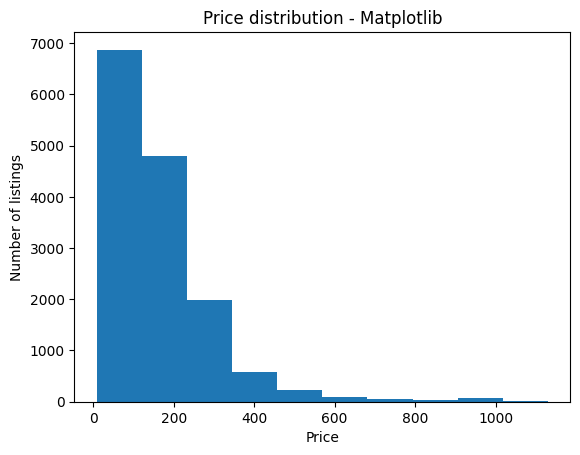

In [ ]:
#MATPLOTLIB - DEFAULT
plt.hist(df['price'])
plt.title('Price distribution - Matplotlib')
plt.xlabel('Price')
plt.ylabel('Number of listings')
plt.show()

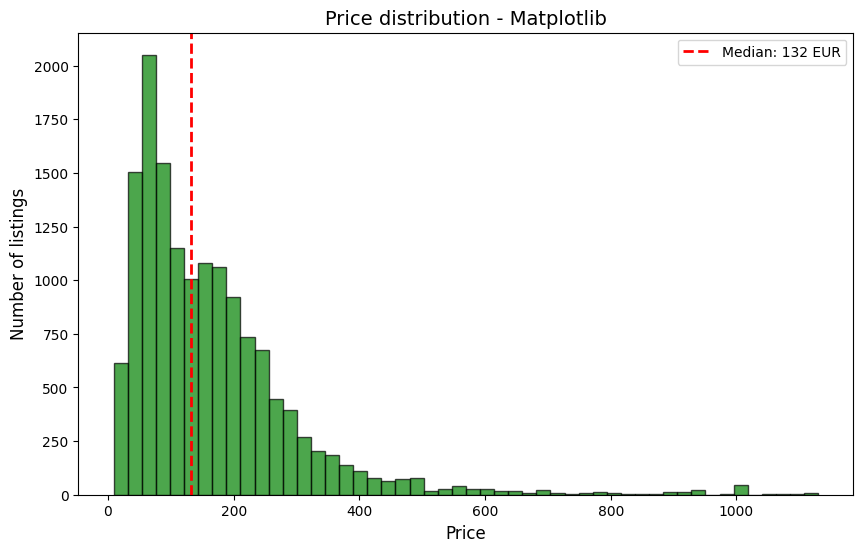

In [ ]:
#MATPLOTLIB -CUSTOM
median_price = df['price'].median()
plt.figure(figsize=(10,6))
plt.hist(df['price'], bins=50, color='green', edgecolor='black', alpha=0.7)
plt.title('Price distribution - Matplotlib', fontsize=14)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Number of listings', fontsize=12)
plt.axvline(median_price, color='red', linestyle='--', linewidth=2, label=f'Median: {df["price"].median():.0f} EUR')
plt.legend()
plt.show()

In [ ]:
#MATPLOTLIB - BENCHMARK
def plot_matplotlib_hist_custom():
  median_price = df['price'].median()
  plt.figure(figsize=(10,6))
  plt.hist(df['price'], bins=50, color='green', edgecolor='black', alpha=0.7)
  plt.title('Price distribution - Matplotlib', fontsize=14)
  plt.xlabel('Price', fontsize=12)
  plt.ylabel('Number of listings', fontsize=12)
  plt.axvline(median_price, color='red', linestyle='--', linewidth=2, label=f'Median: {df["price"].median():.0f} EUR')
  plt.legend()
  plt.close()

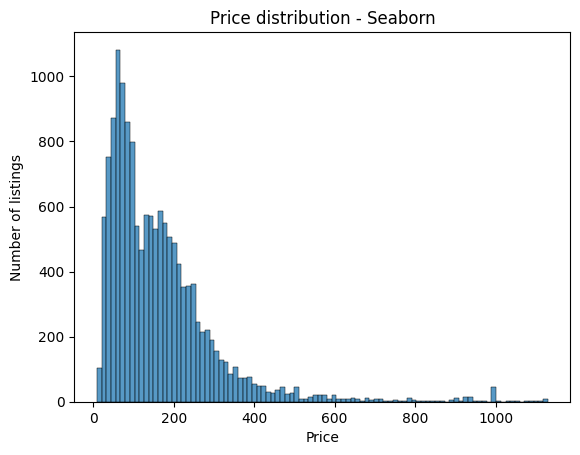

In [ ]:
#SEABORN - DEFAULT
sns.histplot(df['price'])
plt.title('Price distribution - Seaborn')
plt.xlabel('Price')
plt.ylabel('Number of listings')
plt.show()

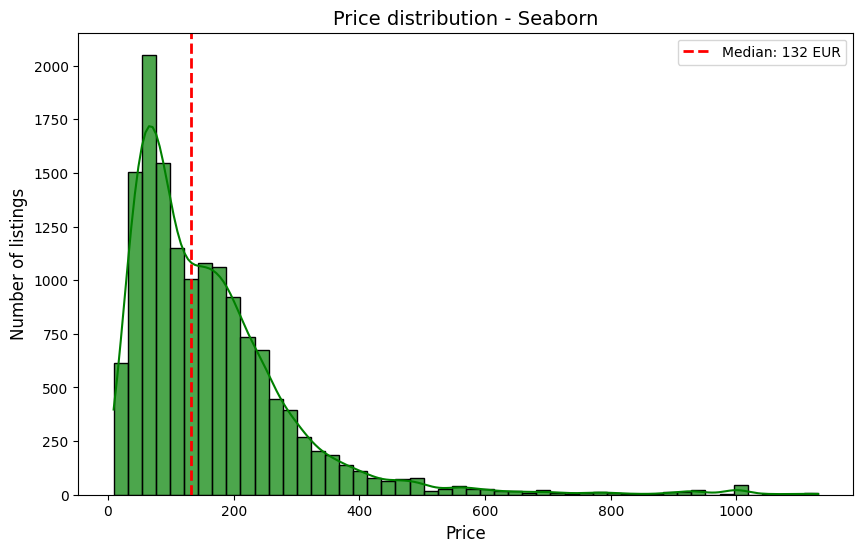

In [ ]:
#SEABORN - CUSTOM
median_price = df['price'].median()
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, color='green', alpha=0.7, kde=True) #kde-val teszem be a vonalat, attol fuggoen hogy True vagy False
plt.title('Price distribution - Seaborn', fontsize=14)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Number of listings', fontsize=12)
plt.axvline(median_price, color='red', linestyle='--', linewidth=2, label=f'Median: {df["price"].median():.0f} EUR')
plt.legend()
plt.show()

In [ ]:
#SEABORN - BENCHMARK
def plot_seaborn_hist_custom():
  median_price = df['price'].median()
  plt.figure(figsize=(10,6))
  sns.histplot(df['price'], bins=50, color='green', alpha=0.7, kde=True) #kde-val teszem be a vonalat, attol fuggoen hogy True vagy False
  plt.title('Price distribution - Seaborn', fontsize=14)
  plt.xlabel('Price', fontsize=12)
  plt.ylabel('Number of listings', fontsize=12)
  plt.axvline(median_price, color='red', linestyle='--', linewidth=2, label=f'Median: {df["price"].median():.0f} EUR')
  plt.legend()
  plt.close()

In [ ]:
#PLOTLY - DEFAULT
fig = px.histogram(df,x='price')
fig.update_layout(xaxis_title = 'Price (EUR)',
                    yaxis_title = 'Number of listings',
                    title = 'Price distribution - Plotly')


In [ ]:
#PLOTLY - CUSTOM
median_price=df['price'].median()
fig = px.histogram(df,
                  x='price',
                  nbins=50,
                  title="Price distribution - Plotly",
                  labels={'price' : 'Price (EUR)', 'count': 'Number of listings'},
                  color_discrete_sequence=['green'])
fig.add_vline(x=median_price,
              line_dash="dash",
              line_color='red',
              annotation_text=f"Median: {df['price'].median():.0f} EUR")
fig.update_layout(xaxis_title = 'Price (EUR)',
                  yaxis_title = 'Number of listings',
                  bargap=0.1,
                  width=900,
                  height=600,
                  title_font_size=14,
                  xaxis_title_font_size=12,
                  yaxis_title_font_size=12)
fig.show()

In [ ]:
#PLOTLY - BENCHMARK
def plot_plotly_hist_custom():
  median_price=df['price'].median()
  fig = px.histogram(df,
                    x='price',
                    nbins=50,
                    title="Price distribution - Plotly",
                    labels={'price' : 'Price (EUR)', 'count': 'Number of listings'},
                    color_discrete_sequence=['green'])
  fig.add_vline(x=median_price,
                line_dash="dash",
                line_color='red',
                annotation_text=f"Median: {df['price'].median():.0f} EUR")
  fig.update_layout(xaxis_title = 'Price (EUR)',
                    yaxis_title = 'Number of listings',
                    bargap=0.1,
                    width=900,
                    height=600,
                    title_font_size=14,
                    xaxis_title_font_size=12,
                    yaxis_title_font_size=12)

In [ ]:
# ÖSSZEHASONLÍTÁS
# változók: price, room_type
# Hogyan változik az ár a szobatípusok szerint?
# Boxplot

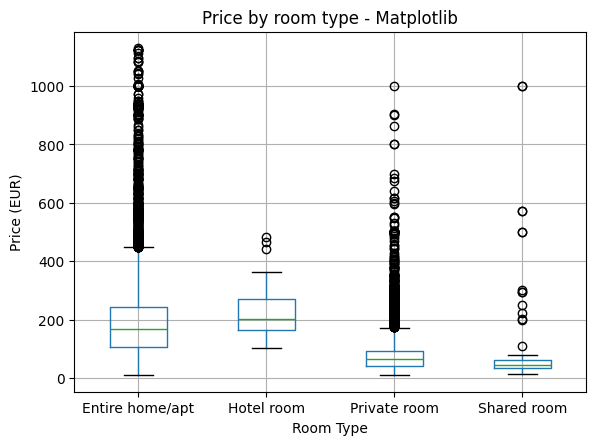

In [ ]:
#MATPLOTLIB - DEFAULT
df.boxplot(column='price', by='room_type')
plt.title('Price by room type - Matplotlib')
plt.suptitle('')
plt.xlabel('Room Type')
plt.ylabel('Price (EUR)')
plt.show()

/tmp/ipykernel_1383/4168096152.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Figure size 1200x800 with 0 Axes>

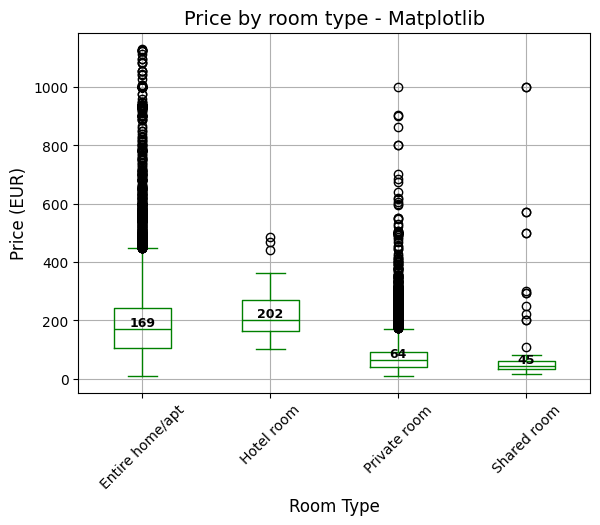

In [ ]:
#MATPLOTLIB - CUSTOM
plt.figure(figsize=(12,8))
df.boxplot(column='price', by='room_type', color='green')
plt.title('Price by room type - Matplotlib', fontsize=14)
plt.suptitle('')
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Price (EUR)', fontsize=12)
plt.xticks(rotation=45) # azert kell hogy jobban olvashatobb legyen

medians = df.groupby('room_type')['price'].median()
for i, median in enumerate(medians):
  plt.text(i+1,
          median+10,
          f'{median:.0f}',
          ha='center',
          fontsize=9,
          fontweight='bold')

plt.show()

In [ ]:
#MATPLOTLIB - BENCHMARK
def plot_matplotlib_box_custom():
  plt.figure(figsize=(12,8))
  df.boxplot(column='price', by='room_type', color='green')
  plt.title('Price by room type - Matplotlib', fontsize=14)
  plt.suptitle('')
  plt.xlabel('Room Type', fontsize=12)
  plt.ylabel('Price (EUR)', fontsize=12)
  plt.xticks(rotation=45) # azert kell hogy jobban olvashatobb legyen

  medians = df.groupby('room_type')['price'].median()
  for i, median in enumerate(medians):
    plt.text(i+1,
            median+10,
            f'{median:.0f}',
            ha='center',
            fontsize=9,
            fontweight='bold')

  plt.close()

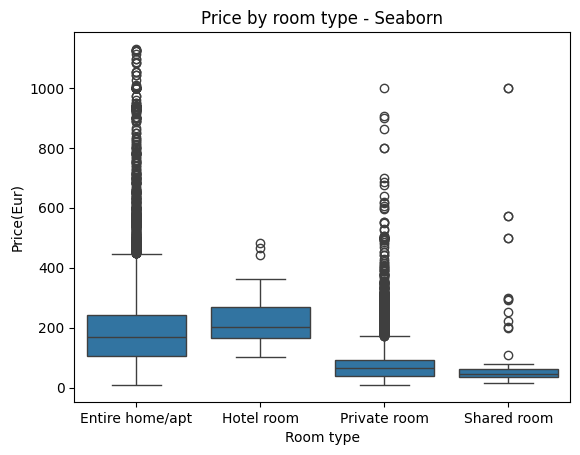

In [ ]:
#SEABORN - DEFAULT
sns.boxplot(data=df, x='room_type', y='price')
plt.title('Price by room type - Seaborn')
plt.xlabel('Room type')
plt.ylabel('Price(Eur)')
plt.show()


/tmp/ipykernel_1383/3019759312.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



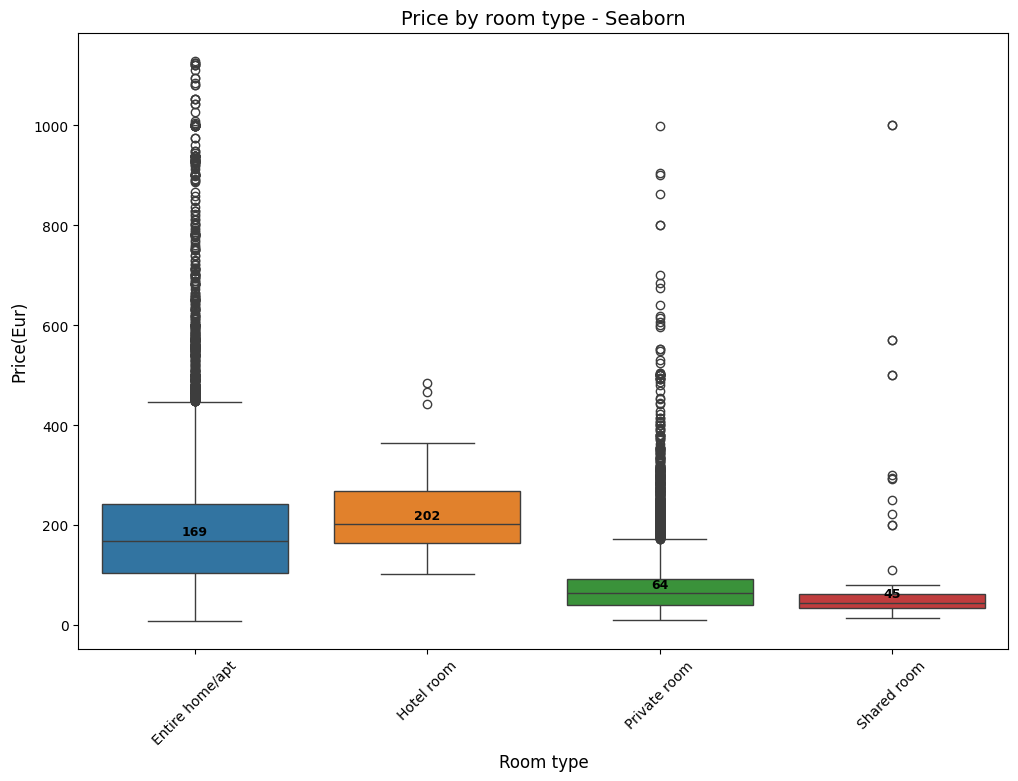

In [ ]:
#SEABORN - CUSTOM
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x='room_type', y='price',hue='room_type') #color='green')
plt.title('Price by room type - Seaborn', fontsize=14)
plt.xlabel('Room type', fontsize=12)
plt.ylabel('Price(Eur)', fontsize=12)
plt.xticks(rotation=45)

medians = df.groupby('room_type')['price'].median()
for i, median in enumerate(medians):
  plt.text(i,
          median+10,
          f'{median:.0f}',
          ha='center',
          fontsize=9,
          fontweight='bold')

plt.show()

In [ ]:
#SEABORN - BENCHMARK
def plot_seaborn_box_custom():
  plt.figure(figsize=(12,8))
  sns.boxplot(data=df, x='room_type', y='price',hue='room_type') #color='green')
  plt.title('Price by room type - Seaborn', fontsize=14)
  plt.xlabel('Room type', fontsize=12)
  plt.ylabel('Price(Eur)', fontsize=12)
  plt.xticks(rotation=45)

  medians = df.groupby('room_type')['price'].median()
  for i, median in enumerate(medians):
    plt.text(i,
            median+10,
            f'{median:.0f}',
            ha='center',
            fontsize=9,
            fontweight='bold')

  plt.close()

In [ ]:
#PLOTLY - DEFAULT
fig = px.box(df,
             x='room_type',
             y='price',
             title="Price by room type - Plotly")
#fig.update_layout(
   # xaxis_title = 'Room type',
    #yaxis_title = 'Price (EUR)')
fig.show()


In [ ]:
#PLOTLY - CUSTOM
fig = px.box(df,
            x='room_type',
            y='price',
            title="Price by room type - Plotly",
            color='room_type',
            labels={'room_type': 'Room Type', 'price': 'Price (EUR)'})
medians= df.groupby('room_type')['price'].median()
for room, median in medians.items():
  fig.add_annotation(x=room,
                    y=median+10,
                    text=f'{median:.0f}',
                    showarrow=False,
                    font=dict(size=10, weight='bold'),
                    bgcolor='white',
                    borderpad=2)
fig.update_layout(
    xaxis_title = 'Room type',
    yaxis_title = 'Price (EUR)',
    width=900,
    height=600,
    bargap=0.1)
fig.show()

/tmp/ipykernel_1383/206493409.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
#PLOTLY - BENCHMARK
def plot_plotly_box_custom():
  fig = px.box(df,
              x='room_type',
              y='price',
              title="Price by room type - Plotly",
              color='room_type',
              labels={'room_type': 'Room Type', 'price': 'Price (EUR)'})
  medians= df.groupby('room_type')['price'].median()
  for room, median in medians.items():
    fig.add_annotation(x=room,
                      y=median+10,
                      text=f'{median:.0f}',
                      showarrow=False,
                      font=dict(size=10, weight='bold'),
                      bgcolor='white',
                      borderpad=2)
  fig.update_layout(
      xaxis_title = 'Room type',
      yaxis_title = 'Price (EUR)',
      width=900,
      height=600,
      bargap=0.1)

In [ ]:
# Kapcsolat
# változók: price, availability_365
# Van kapcsolat az ár és a rendelkezésre állás között?
# Scatter plot

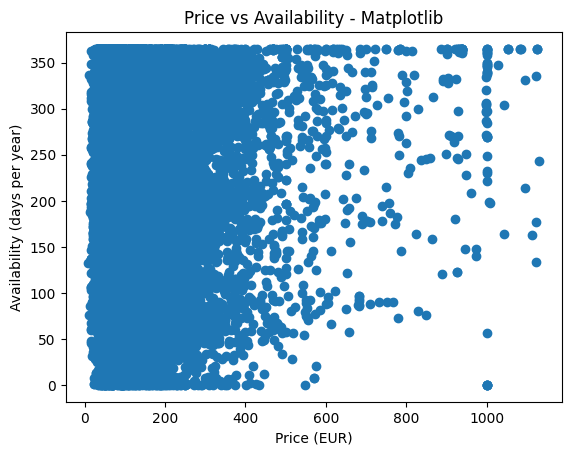

In [ ]:
#MATPLOTLIB - DEFAULT
plt.scatter(df['price'], df['availability_365'])
plt.title('Price vs Availability - Matplotlib')
plt.xlabel('Price (EUR)')
plt.ylabel('Availability (days per year)')
plt.show()


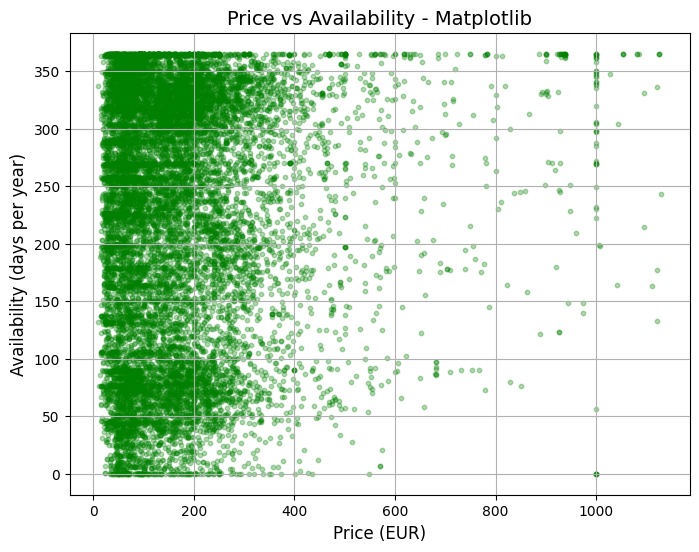

In [ ]:
#MATPLOTLIB - CUSTOM
plt.figure(figsize=(8,6))
plt.scatter(df['price'], df['availability_365'], alpha=0.3, color='green', s=10)
plt.title('Price vs Availability - Matplotlib', fontsize=14)
plt.xlabel('Price (EUR)', fontsize=12)
plt.ylabel('Availability (days per year)', fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
#MATPLOTLIB - BENCHMARK
def plot_matplotlib_scat_custom():
  plt.figure(figsize=(8,6))
  plt.scatter(df['price'], df['availability_365'], alpha=0.3, color='green', s=10)
  plt.title('Price vs Availability - Matplotlib', fontsize=14)
  plt.xlabel('Price (EUR)', fontsize=12)
  plt.ylabel('Availability (days per year)', fontsize=12)
  plt.grid(True)
  plt.close()

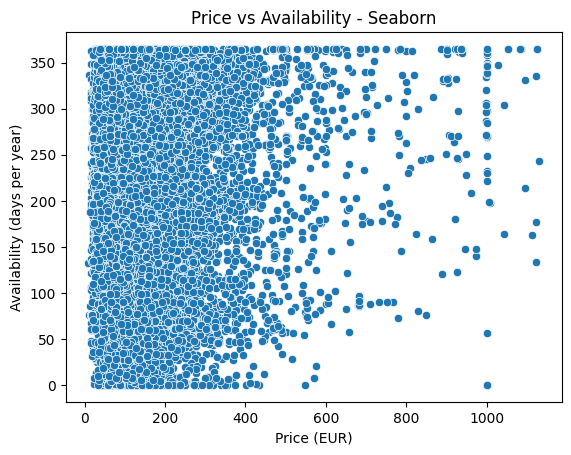

In [ ]:
#SEABORN - DEFAULT
sns.scatterplot(data=df, x='price', y='availability_365')
plt.title('Price vs Availability - Seaborn')
plt.xlabel('Price (EUR)')
plt.ylabel('Availability (days per year)')
plt.show()


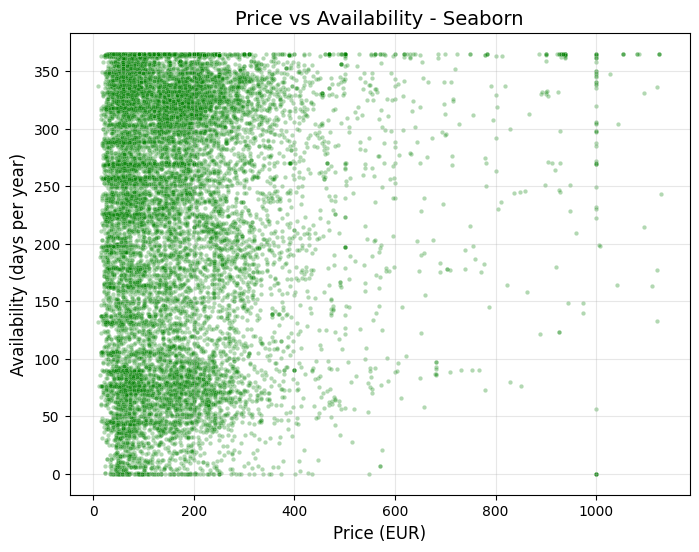

In [ ]:
#SEABORN - CUSTOM
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='price', y='availability_365', alpha=0.3, color='green', s=10)
plt.title('Price vs Availability - Seaborn', fontsize=14)
plt.xlabel('Price (EUR)', fontsize=12)
plt.ylabel('Availability (days per year)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#SEABORN - BENCHMARK
def plot_seaborn_scat_custom():
  plt.figure(figsize=(8,6))
  sns.scatterplot(data=df, x='price', y='availability_365', alpha=0.3, color='green', s=10)
  plt.title('Price vs Availability - Seaborn', fontsize=14)
  plt.xlabel('Price (EUR)', fontsize=12)
  plt.ylabel('Availability (days per year)', fontsize=12)
  plt.grid(True, alpha=0.3)
  plt.close()

In [ ]:
#PLOTLY - DEFAULT
fig = px.scatter(df,
             x='price',
             y='availability_365',
             title='Price vs Availability - Plotly',
             labels={'price': 'Price (EUR)', 'availability_365': 'Availability (days per year)'})
fig.update_layout(
    xaxis_title='Price (EUR)',
    yaxis_title='Availability (days per year)'
    )
fig.show()

In [ ]:
#PLOTLY - CUSTOM
fig = px.scatter(df,
            x='price',
            y='availability_365',
            title='Price vs Availability - Plotly',
            labels={'price': 'Price (EUR)', 'availability_365': 'Availability (days per year)'},
            color_discrete_sequence=['green'],
            opacity=0.4)
fig.update_traces(marker=dict(size=4))
fig.update_layout(
    xaxis_title='Price (EUR)',
    yaxis_title='Availability (days per year)',
    width=800)
fig.show()

In [ ]:
#PLOTLY - BENCHMARK
def plot_plotly_scat_custom():
  fig = px.scatter(df,
              x='price',
              y='availability_365',
              title='Price vs Availability - Plotly',
              labels={'price': 'Price (EUR)', 'availability_365': 'Availability (days per year)'},
              color_discrete_sequence=['green'],
              opacity=0.4)
  fig.update_traces(marker=dict(size=4))
  fig.update_layout(
      xaxis_title='Price (EUR)',
      yaxis_title='Availability (days per year)',
      width=800)

In [ ]:
results = []

for name, func in [
    ("matplotlib_hist", plot_matplotlib_hist_custom),
    ("seaborn_hist", plot_seaborn_hist_custom),
    ("plotly_hist", plot_plotly_hist_custom),
    ("matplotlib_box", plot_matplotlib_box_custom),
    ("seaborn_box", plot_seaborn_box_custom),
    ("plotly_box", plot_plotly_box_custom),
    ("matplotlib_scatter", plot_matplotlib_scat_custom),
    ("seaborn_scatter", plot_seaborn_scat_custom),
    ("plotly_scatter", plot_plotly_scat_custom)
]:
    mean, std = benchmark(func, repeats=10)

    results.append({
        "library": name,
        "mean_time": mean,
        "std_time": std
    })


/tmp/ipykernel_1383/2315360718.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1383/2315360718.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1383/2315360718.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1383/2315360718.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=F

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

...

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [ ]:
#FUTÁSI IDŐK EREDMÉNYE
results_df = pd.DataFrame(results)
print(results_df)

              library  mean_time  std_time
0     matplotlib_hist   0.064064  0.055605
1        seaborn_hist   0.216248  0.041175
2         plotly_hist   0.041544  0.001443
3      matplotlib_box   0.063193  0.070019
4         seaborn_box   0.090523  0.002770
5          plotly_box   0.053082  0.004780
6  matplotlib_scatter   0.009684  0.000760
7     seaborn_scatter   0.043820  0.000980
8      plotly_scatter   0.034486  0.003678
